In [3]:
%load_ext autoreload
%autoreload 2

In [4]:
import numpy as np
import h5py
import matplotlib.pyplot as plt
from numba import jit
import scipy
import pandas as pd
import seaborn as sns

In [9]:
H5_PATH = '../output/Gliese_667_observed_ev0.2_iv000.hdf5'

def load_hdf5_data(H5_PATH):
    with h5py.File(H5_PATH, "r") as f:
        keys = sorted(
            [k for k in f.keys() if k.startswith("Step_")],
            key=lambda s: int(s.split("_")[1])
        )
        t_list, pos_list, mass_list, ptype_list, energy_list, temperature_list, in_hz_list = [], [], [], [], [], [], []
        hz_inner_radius_list, hz_outer_radius_list = [], []
        a_list, e_list, inc_list = [], [], []
        for k in keys:
            g = f[k]
            t_list.append(g["time"][:])
            pos_list.append(g["pos"][:])
            mass_list.append(g["mass"][:])
            ptype_list.append(g["ptype"][:])
            '''
            hz_inner_radius_list.append(g["hz_inner_radius"][:])
            hz_outer_radius_list.append(g["hz_outer_radius"][:])
            energy_list.append(g["energy"][:])
            temperature_list.append(g["temperature"][:])
            in_hz_list.append(g["in_hz"][:])
            a_list.append(g["a"][:])
            e_list.append(g["e"][:])
            inc_list.append(g["inc"][:])
            '''
    t = np.concatenate(t_list)
    pos = np.concatenate(pos_list)
    mass = np.concatenate(mass_list)
    ptype = np.concatenate(ptype_list)
    #hz_inner_radius = np.concatenate(hz_inner_radius_list)
    #hz_outer_radius = np.concatenate(hz_outer_radius_list)
    #energy = np.concatenate(energy_list)
    #temperature = np.concatenate(temperature_list)
    #in_hz = np.concatenate(in_hz_list)
    #a = np.concatenate(a_list)
    #e = np.concatenate(e_list)
    #inc = np.concatenate(inc_list)

    n_particles = mass.shape[1]
    if pos.ndim == 2:
        pos = pos.reshape(pos.shape[0], n_particles, 3)

    return t, pos, mass, ptype#, hz_inner_radius, hz_outer_radius, energy, temperature, in_hz, a, e, inc

def determine_system(mass, pos, ptype):
    star_idx = np.where(ptype[0] == 0)[0]
    planet_idx = np.where(ptype[0] == 1)[0]
    m0 = mass[0]

    iA, iB = star_idx[0], star_idx[1]
    iC = star_idx[2] if len(star_idx) > 2 else None
    mA, mB = m0[iA], m0[iB]
    r_com_bin = (mA * pos[:, iA, :] + mB * pos[:, iB, :]) / (mA + mB)

    return star_idx, planet_idx, iA, iB, iC, mA, mB, r_com_bin

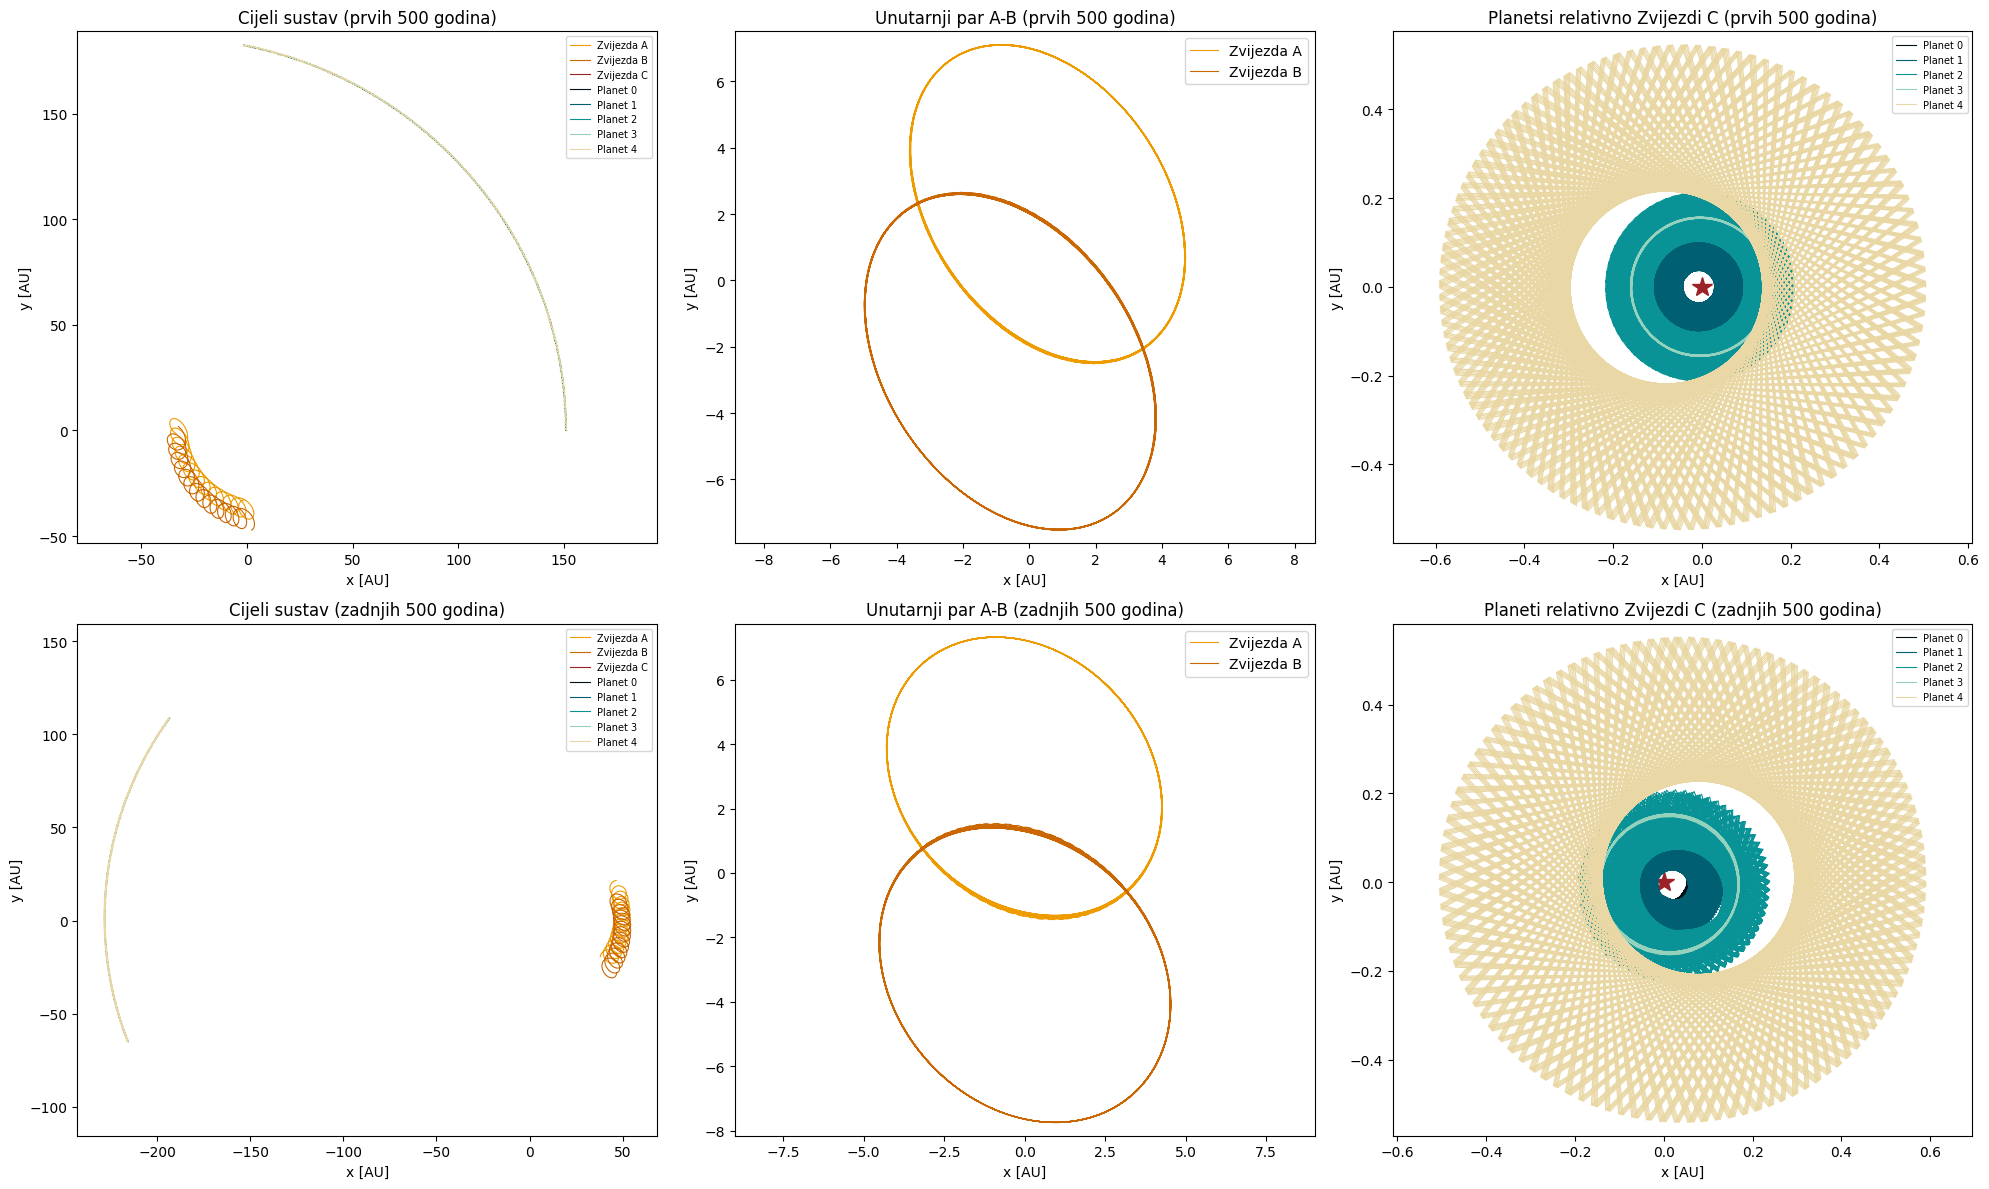

In [ ]:
#, hz_inner_radius, hz_outer_radius, energy, temperature, in_hz, a, e, inc = 
t, pos, mass, ptype = load_hdf5_data(H5_PATH)
star_idx, planet_idx, iA, iB, iC, mA, mB, r_com_bin = determine_system(mass, pos, ptype)

star_colors = {0: '#ee9b00', 1: '#ca6702', 2: '#9b2226'}
star_labels = {0: 'A', 1: 'B', 2: 'C'}
planet_colors = ['#001219', '#005f73', '#0a9396', '#94d2bd', '#e9d8a6', '#bb3e03', '#ae2012']

# Time window for start/end comparison (in years)
t_window = 100
mask_start = t < t_window
mask_end = t > (t[-1] - t_window)

fig, axes = plt.subplots(2, 3, figsize=(20, 12))

# ====== TOP ROW: First orbits ======
ax = axes[0, 0]
ax.set_title(f"Cijeli sustav (prvih {t_window} godina)")
for i in star_idx:
    ax.plot(pos[mask_start, i, 0], pos[mask_start, i, 1],
            label=f"Zvijezda {star_labels.get(i, i)}", color=star_colors.get(i, '#001219'), lw=0.8)
for j, i in enumerate(planet_idx):
    ax.plot(pos[mask_start, i, 0], pos[mask_start, i, 1],
            label=f"Planet {j}", color=planet_colors[j], lw=0.8)
ax.set_xlabel("x [AU]"); ax.set_ylabel("y [AU]")
ax.axis("equal"); ax.legend(fontsize=7)

ax = axes[0, 1]
ax.set_title(f"Unutarnji par A-B (prvih {t_window} godina)")
for i in [iA, iB]:
    ax.plot(pos[mask_start, i, 0] - r_com_bin[mask_start, 0],
            pos[mask_start, i, 1] - r_com_bin[mask_start, 1],
            label=f"Zvijezda {star_labels.get(i, i)}", color=star_colors.get(i, '#001219'), lw=0.8)
ax.set_xlabel("x [AU]"); ax.set_ylabel("y [AU]")
ax.axis("equal"); ax.legend()

ax = axes[0, 2]
if len(planet_idx) > 0:
    dists_to_stars = [np.linalg.norm(pos[0, planet_idx[0], :] - pos[0, s, :]) for s in star_idx]
    host_idx = star_idx[np.argmin(dists_to_stars)]
    #hz_inner = hz_inner_radius[0, planet_idx[0]]
    #hz_outer = hz_outer_radius[0, planet_idx[0]]
    ax.set_title(f"Planetsi relativno Zvijezdi {star_labels.get(host_idx, host_idx)} (prvih {t_window} godina)")
    ax.plot(0, 0, '*', color=star_colors.get(host_idx, '#001219'), ms=15)
    #for hz_r, lbl, style in [(hz_inner, 'HZ unutarnja', '--'), (hz_outer, 'HZ vanjska', ':')]:
        #ax.add_patch(plt.Circle((0, 0), hz_r, fill=False, ls=style, lw=2.2, color='#9b2226', alpha=0.9, label=lbl))
    for j, i in enumerate(planet_idx):
        ax.plot(pos[mask_start, i, 0] - pos[mask_start, host_idx, 0],
                pos[mask_start, i, 1] - pos[mask_start, host_idx, 1],
                label=f"Planet {j}", color=planet_colors[j], lw=0.8)
    ax.set_xlabel("x [AU]"); ax.set_ylabel("y [AU]")
    ax.axis("equal"); ax.legend(fontsize=7)

# ====== BOTTOM ROW: Last orbits ======
ax = axes[1, 0]
ax.set_title(f"Cijeli sustav (zadnjih {t_window} godina)")
for i in star_idx:
    ax.plot(pos[mask_end, i, 0], pos[mask_end, i, 1],
            label=f"Zvijezda {star_labels.get(i, i)}", color=star_colors.get(i, '#001219'), lw=0.8)
for j, i in enumerate(planet_idx):
    ax.plot(pos[mask_end, i, 0], pos[mask_end, i, 1],
            label=f"Planet {j}", color=planet_colors[j], lw=0.8)
ax.set_xlabel("x [AU]"); ax.set_ylabel("y [AU]")
ax.axis("equal"); ax.legend(fontsize=7)

ax = axes[1, 1]
ax.set_title(f"Unutarnji par A-B (zadnjih {t_window} godina)")
for i in [iA, iB]:
    ax.plot(pos[mask_end, i, 0] - r_com_bin[mask_end, 0],
            pos[mask_end, i, 1] - r_com_bin[mask_end, 1],
            label=f"Zvijezda {star_labels.get(i, i)}", color=star_colors.get(i, '#001219'), lw=0.8)
ax.set_xlabel("x [AU]"); ax.set_ylabel("y [AU]")
ax.axis("equal"); ax.legend()

ax = axes[1, 2]
if len(planet_idx) > 0:
    ax.set_title(f"Planeti relativno Zvijezdi {star_labels.get(host_idx, host_idx)} (zadnjih {t_window} godina)")
    ax.plot(0, 0, '*', color=star_colors.get(host_idx, '#001219'), ms=15)
    #for hz_r, lbl, style in [(hz_inner, 'HZ unutarnja', '--'), (hz_outer, 'HZ vanjska', ':')]:
        #ax.add_patch(plt.Circle((0, 0), hz_r, fill=False, ls=style, lw=2.2, color='#9b2226', alpha=0.9, label=lbl))
    for j, i in enumerate(planet_idx):
        ax.plot(pos[mask_end, i, 0] - pos[mask_end, host_idx, 0],
                pos[mask_end, i, 1] - pos[mask_end, host_idx, 1],
                label=f"Planet {j}", color=planet_colors[j], lw=0.8)
    ax.set_xlabel("x [AU]"); ax.set_ylabel("y [AU]")
    ax.axis("equal"); ax.legend(fontsize=7)

plt.tight_layout()
plt.savefig('../plots/Gliese667_e0.0_i00_orbits.png', dpi=300)
plt.show()

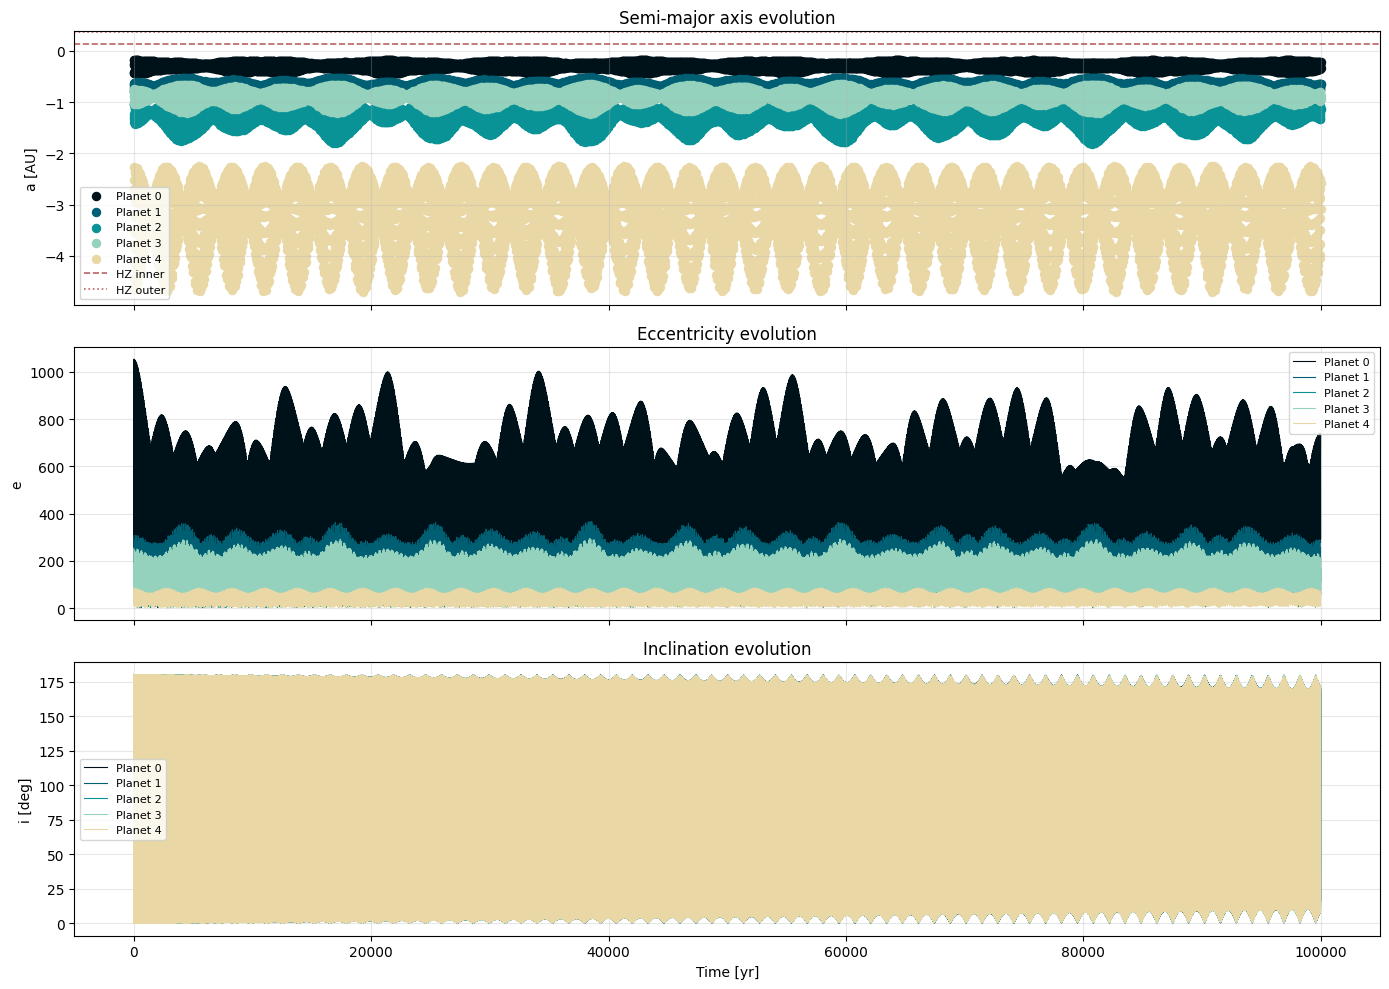

In [18]:
# --- Orbital elements evolution ---
fig, axes = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

for j, i in enumerate(planet_idx):
    color = planet_colors[j]
    axes[0].scatter(t, a[:, i], label=f'Planet {j}', color=color, lw=0.8)
    axes[1].plot(t, e[:, i], label=f'Planet {j}', color=color, lw=0.8)
    axes[2].plot(t, np.degrees(inc[:, i]), label=f'Planet {j}', color=color, lw=0.8)

# Mark HZ boundaries on the semi-major axis plot
if len(planet_idx) > 0:
    axes[0].axhline(hz_inner, color='#9b2226', ls='--', lw=1.2, alpha=0.7, label='HZ inner')
    axes[0].axhline(hz_outer, color='#9b2226', ls=':', lw=1.2, alpha=0.7, label='HZ outer')

axes[0].set_ylabel('a [AU]')
axes[0].set_title('Semi-major axis evolution')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_ylabel('e')
axes[1].set_title('Eccentricity evolution')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

axes[2].set_ylabel('i [deg]')
axes[2].set_xlabel('Time [yr]')
axes[2].set_title('Inclination evolution')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/Gliese667_e0.0_i00_orbital_elements.png', dpi=300)
plt.show()

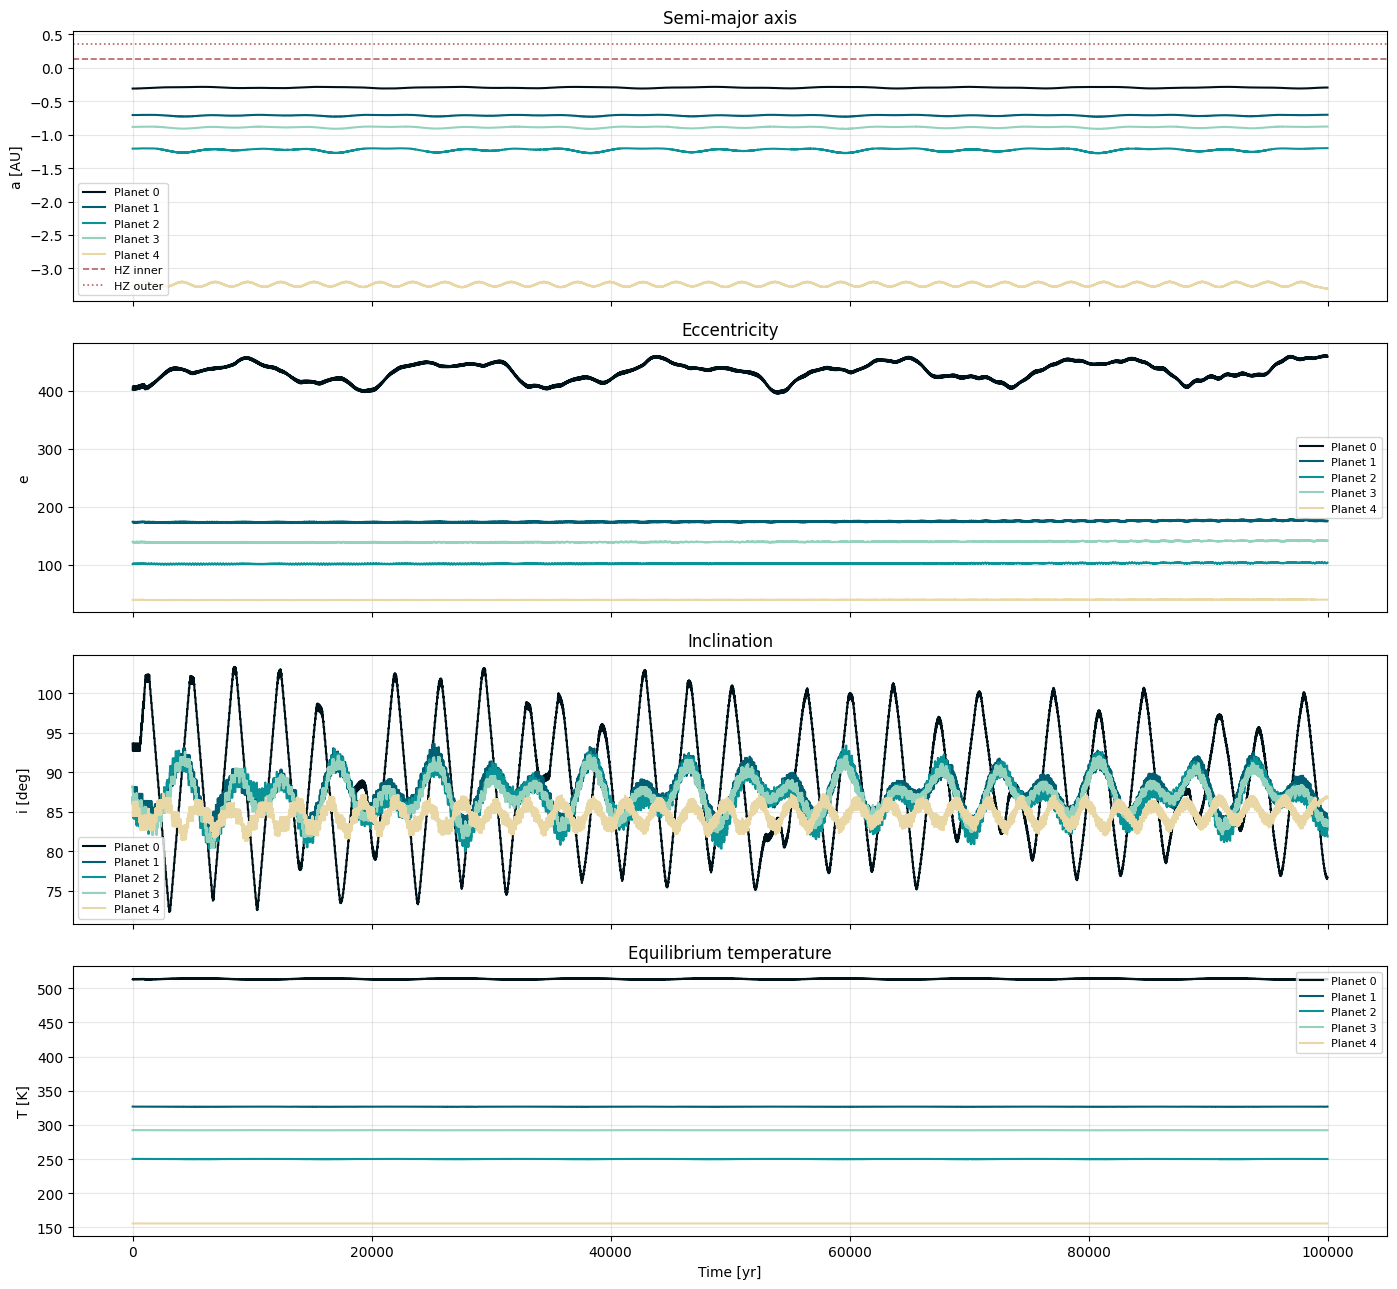

In [23]:
# --- Orbital elements + temperature with running average ---
from scipy.ndimage import uniform_filter1d

window = 200  # snapshots to average (~2000 yr) — adjust as needed

fig, axes = plt.subplots(4, 1, figsize=(14, 13), sharex=True)

for j, i in enumerate(planet_idx):
    color = planet_colors[j]

    a_smooth = uniform_filter1d(a[:, i], size=window)
    e_smooth = uniform_filter1d(e[:, i], size=window)
    i_smooth = uniform_filter1d(np.degrees(inc[:, i]), size=window)
    t_smooth = uniform_filter1d(temperature[:, i], size=window)

    axes[0].plot(t, a_smooth, label=f'Planet {j}', color=color, lw=1.5)
    axes[1].plot(t, e_smooth, label=f'Planet {j}', color=color, lw=1.5)
    axes[2].plot(t, i_smooth, label=f'Planet {j}', color=color, lw=1.5)
    axes[3].plot(t, t_smooth, label=f'Planet {j}', color=color, lw=1.5)

if len(planet_idx) > 0:
    axes[0].axhline(hz_inner, color='#9b2226', ls='--', lw=1.2, alpha=0.7, label='HZ inner')
    axes[0].axhline(hz_outer, color='#9b2226', ls=':', lw=1.2, alpha=0.7, label='HZ outer')

axes[0].set_ylabel('a [AU]')
axes[0].set_title('Semi-major axis')
axes[0].legend(fontsize=8)
axes[0].grid(alpha=0.3)

axes[1].set_ylabel('e')
axes[1].set_title('Eccentricity')
axes[1].legend(fontsize=8)
axes[1].grid(alpha=0.3)

axes[2].set_ylabel('i [deg]')
axes[2].set_title('Inclination')
axes[2].legend(fontsize=8)
axes[2].grid(alpha=0.3)

axes[3].set_ylabel('T [K]')
axes[3].set_xlabel('Time [yr]')
axes[3].set_title('Equilibrium temperature')
axes[3].legend(fontsize=8)
axes[3].grid(alpha=0.3)

plt.tight_layout()
plt.savefig('../plots/Gliese667_e0.0_i00_orbital_elements_smooth.png', dpi=300)
plt.show()

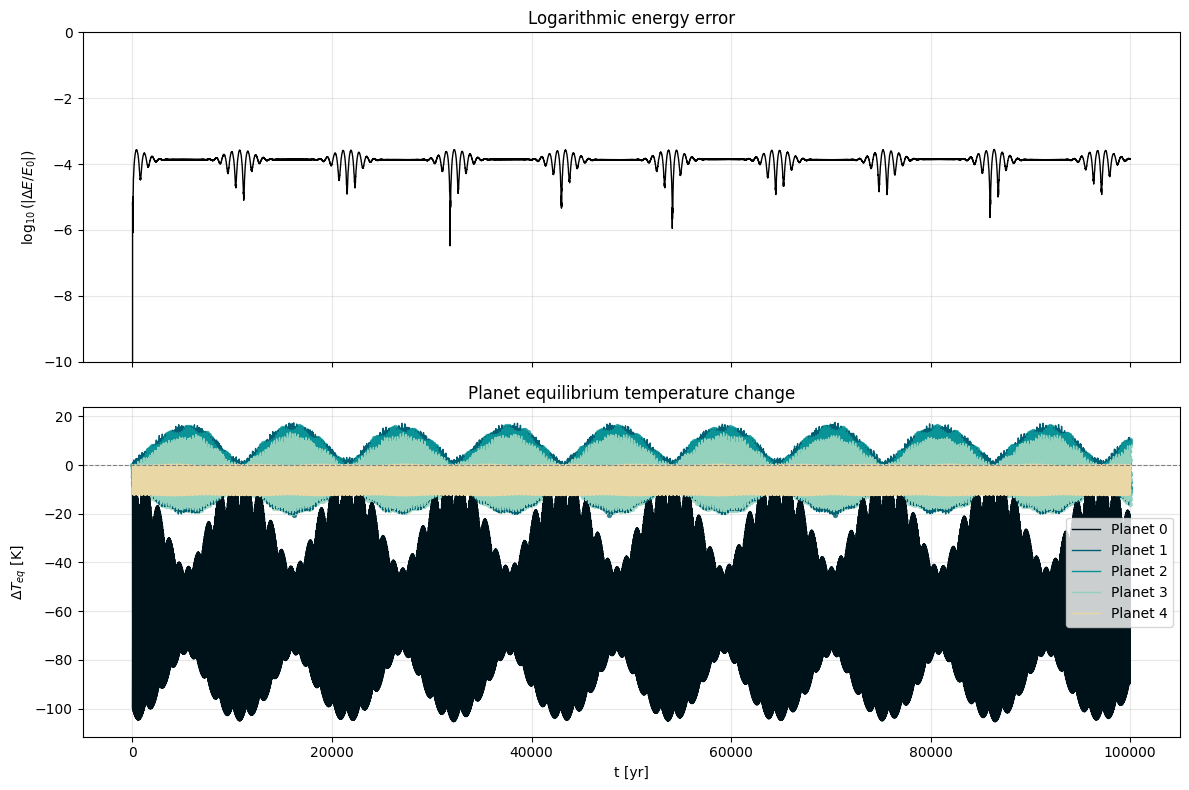

In [21]:
planet_idx = np.where(ptype[0] == 1)[0]
energy0 = energy[0]
energy_err = np.abs((energy - energy0) / energy0)
energy_err = np.maximum(energy_err, np.finfo(float).tiny)

fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(t, np.log10(energy_err), color='black', lw=1.0)
#axes[0].set_xlim([0.1, 10001])
axes[0].set_ylim([-10, 0])
axes[0].set_ylabel(r'$\log_{10}(|\Delta E / E_0|)$')
axes[0].set_title('Logarithmic energy error')
axes[0].grid(alpha=0.3)

for j, i in enumerate(planet_idx):
    delta_temp = temperature[:, i] - temperature[0, i]
    color = planet_colors[j] if 'planet_colors' in locals() and j < len(planet_colors) else None
    axes[1].plot(t, delta_temp, label=f'Planet {j}', color=color, lw=1.0)
    if np.any(np.isfinite(in_hz[:, i])):
        hz_mask = in_hz[:, i] > 0.5
        axes[1].scatter(t[hz_mask], delta_temp[hz_mask], s=8, color=color, alpha=0.7)

axes[1].axhline(0.0, color='0.5', linestyle='--', lw=0.8)
axes[1].set_xlabel('t [yr]')
axes[1].set_ylabel(r'$\Delta T_{eq}$ [K]')
axes[1].set_title('Planet equilibrium temperature change')
axes[1].grid(alpha=0.3)
axes[1].legend()

plt.tight_layout()
plt.show()

In [20]:
for j, i in enumerate(planet_idx):
    hz_fraction = np.nanmean(in_hz[:, i]) if np.any(np.isfinite(in_hz[:, i])) else np.nan
    print(f'Planet {j}: T_eq(0) = {temperature[0, i]:.3f} K,  T_eq(final) = {temperature[-1, i]:.3f} K,  in HZ fraction = {hz_fraction:.3f}')

Planet 0: T_eq(0) = 574.968 K,  T_eq(final) = 487.380 K,  in HZ fraction = 0.000
Planet 1: T_eq(0) = 329.966 K,  T_eq(final) = 340.115 K,  in HZ fraction = 0.000
Planet 2: T_eq(0) = 252.776 K,  T_eq(final) = 249.092 K,  in HZ fraction = 1.000
Planet 3: T_eq(0) = 296.886 K,  T_eq(final) = 280.802 K,  in HZ fraction = 0.999
Planet 4: T_eq(0) = 162.503 K,  T_eq(final) = 161.060 K,  in HZ fraction = 0.000
